<a href="https://colab.research.google.com/github/mal0ware/APCSA/blob/main/SIG_FIN_Trading_Bot_(basic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd

In [ ]:
data = yf.download("NKE", start="2025-01-01", end="2025-10-01")
data.head()

/tmp/ipython-input-1222316861.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("NKE", start="2025-01-01", end="2025-10-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NKE,NKE,NKE,NKE,NKE
Date,,,,,
2025-01-02,72.438652,75.408179,72.015839,74.975531,10883400
2025-01-03,72.084663,72.949960,71.789682,72.684468,10083500
2025-01-06,70.796562,73.077784,70.767065,72.517312,14947300
2025-01-07,70.885063,72.212505,70.776909,71.189887,10463500
2025-01-08,70.098427,70.619567,69.823108,70.363911,11855000


In [ ]:
data['MA20'] = data['Close'].rolling(window=20, min_periods=1).mean() #short term
data['MA50'] = data['Close'].rolling(window=50, min_periods=1).mean() #long term
data.tail()

Price,Close,High,Low,Open,Volume,MA20,MA50
Ticker,NKE,NKE,NKE,NKE,NKE,,
Date,,,,,,,
2025-09-24,71.220001,71.529999,70.449997,70.669998,10024500,73.713679,74.742477
2025-09-25,69.239998,71.160004,69.050003,71.160004,13075300,73.292857,74.692732
2025-09-26,69.309998,69.440002,68.029999,69.379997,15627600,72.882500,74.626878
2025-09-29,69.550003,69.959999,68.739998,69.769997,18479300,72.511500,74.575972
2025-09-30,69.730003,70.209999,68.820000,70.070000,40567700,72.283500,74.497825


<Axes: xlabel='Date'>

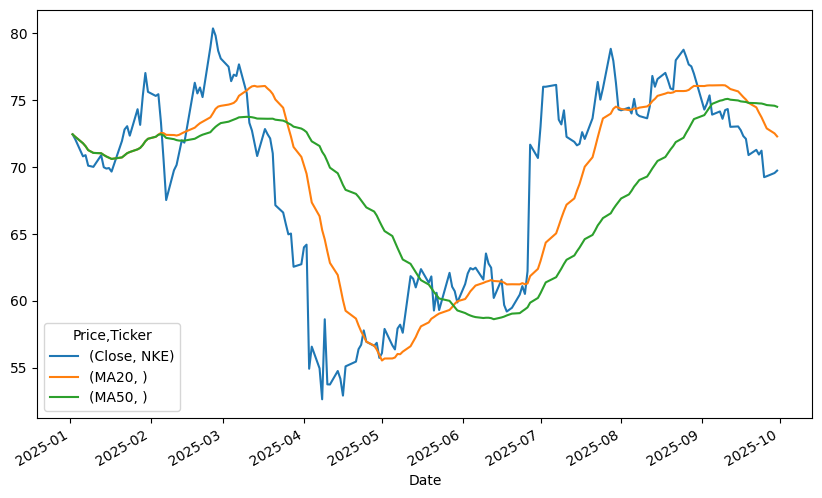

In [ ]:
data[['Close', 'MA20', 'MA50']].plot(figsize=(10,6))

In [ ]:
data['Signal'] = 0
data.loc[data['MA20'] > data['MA50'], 'Signal'] = 1   # Buy
data.loc[data['MA20'] < data['MA50'], 'Signal'] = -1  # Sell

In [ ]:
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Signal
Ticker,NKE,NKE,NKE,NKE,NKE,,,
Date,,,,,,,,
2025-01-02,72.438652,75.408179,72.015839,74.975531,10883400,72.438652,72.438652,0
2025-01-03,72.084663,72.949960,71.789682,72.684468,10083500,72.261658,72.261658,0
2025-01-06,70.796562,73.077784,70.767065,72.517312,14947300,71.773293,71.773293,0
2025-01-07,70.885063,72.212505,70.776909,71.189887,10463500,71.551235,71.551235,0
2025-01-08,70.098427,70.619567,69.823108,70.363911,11855000,71.260674,71.260674,0
...,...,...,...,...,...,...,...,...
2025-09-24,71.220001,71.529999,70.449997,70.669998,10024500,73.713679,74.742477,-1
2025-09-25,69.239998,71.160004,69.050003,71.160004,13075300,73.292857,74.692732,-1
